# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 25 - 3er bimestre 2026

## **Alumno 1:** Ignacio Rubiolo

## **Alumno 2:** Lourdes Tolotto

## Imports y configuración

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


Dispositivo: cpu


## Carga de los datos

In [2]:
train_path = "adult_train.csv"
val_path = "adult_val.csv"

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")

display(train_df.head())


Train shape: (30162, 14)
Validation shape: (15060, 14)


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


### Estructura General

In [3]:
print("Información del conjunto de entrenamiento:")
train_df.info()

print("\nValores faltantes:")
display(train_df.isna().sum().to_frame("missing_values"))

print(f"\nDuplicados en train: {train_df.duplicated().sum()}")
print(f"Duplicados en validation: {val_df.duplicated().sum()}")


Información del conjunto de entrenamiento:
<class 'pandas.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  str  
 2   education       30162 non-null  str  
 3   marital-status  30162 non-null  str  
 4   occupation      30162 non-null  str  
 5   relationship    30162 non-null  str  
 6   race            30162 non-null  str  
 7   sex             30162 non-null  str  
 8   capital-gain    30162 non-null  int64
 9   capital-loss    30162 non-null  int64
 10  hours-per-week  30162 non-null  int64
 11  skill-profile   30162 non-null  str  
 12  native-country  30162 non-null  str  
 13  income          30162 non-null  str  
dtypes: int64(4), str(10)
memory usage: 3.2 MB

Valores faltantes:


,missing_values
age,0
workclass,0
education,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0



Duplicados en train: 479
Duplicados en validation: 118


### Distribución del target

,count,percentage
income,,
<=50K,22654,75.11
>50K,7508,24.89


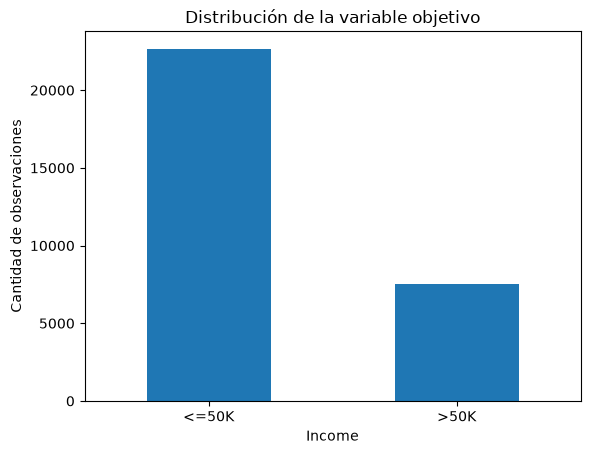

In [4]:
target_counts = train_df["income"].value_counts()
target_percentages = train_df["income"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2),
})

display(target_summary)

target_counts.plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Income")
plt.ylabel("Cantidad de observaciones")
plt.xticks(rotation=0)
plt.show()


### Cardinalidad de variables categóricas

In [5]:
categorical_columns = train_df.select_dtypes(
    include=["object", "string"]
).columns.tolist()
categorical_columns.remove("income")

cardinality = (
    train_df[categorical_columns]
    .nunique()
    .sort_values(ascending=False)
    .to_frame("n_unique")
)

cardinality["high_cardinality"] = cardinality["n_unique"] >= 10

display(cardinality)


,n_unique,high_cardinality
skill-profile,80,True
native-country,41,True
education,16,True
occupation,14,True
workclass,7,False
marital-status,7,False
relationship,6,False
race,5,False
sex,2,False


In [6]:
for column in categorical_columns:
    summary = (
        train_df[column]
        .value_counts(dropna=False)
        .head(10)
        .to_frame("count")
    )
    summary["percentage"] = (
        100 * summary["count"] / len(train_df)
    ).round(2)

    print(f"\n{column} — {train_df[column].nunique()} categorías")
    display(summary)



workclass — 7 categorías


,count,percentage
workclass,,
Private,22286,73.89
Self-emp-not-inc,2499,8.29
Local-gov,2067,6.85
State-gov,1279,4.24
Self-emp-inc,1074,3.56
Federal-gov,943,3.13
Without-pay,14,0.05



education — 16 categorías


,count,percentage
education,,
HS-grad,9840,32.62
Some-college,6678,22.14
Bachelors,5044,16.72
Masters,1627,5.39
Assoc-voc,1307,4.33
11th,1048,3.47
Assoc-acdm,1008,3.34
10th,820,2.72
7th-8th,557,1.85



marital-status — 7 categorías


...

,count,percentage
sex,,
Male,20380,67.57
Female,9782,32.43



skill-profile — 80 categorías


,count,percentage
skill-profile,,
customer_service_retail,2720,9.02
food_service_kitchen_basic,1668,5.53
agriculture_field_work,1638,5.43
maintenance_janitorial,1610,5.34
manufacturing_assembly,1476,4.89
logistics_warehouse_basic,1465,4.86
customer_service_hospitality,1452,4.81
sales_retail_basic,1430,4.74
trade_construction_basic,1182,3.92



native-country — 41 categorías


,count,percentage
native-country,,
United-States,27504,91.19
Mexico,610,2.02
Philippines,188,0.62
Germany,128,0.42
Puerto-Rico,109,0.36
Canada,107,0.35
India,100,0.33
El-Salvador,100,0.33
Cuba,92,0.31


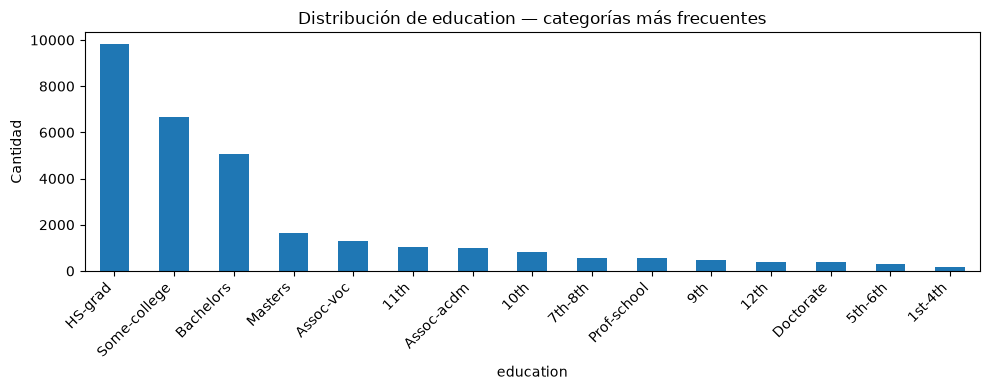

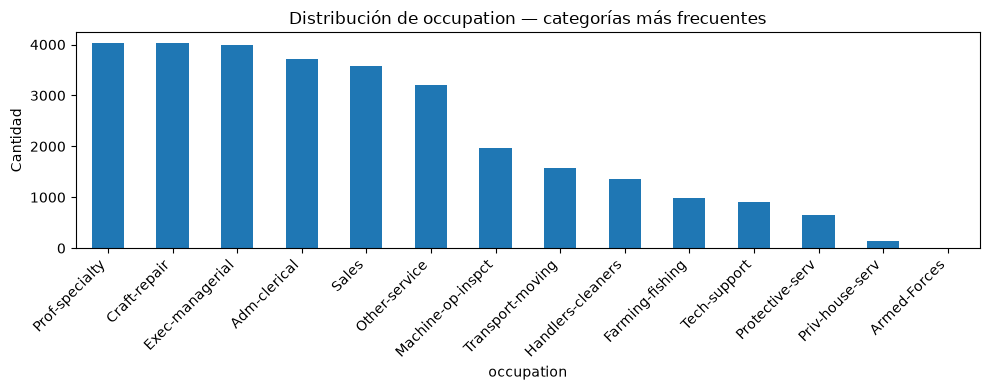

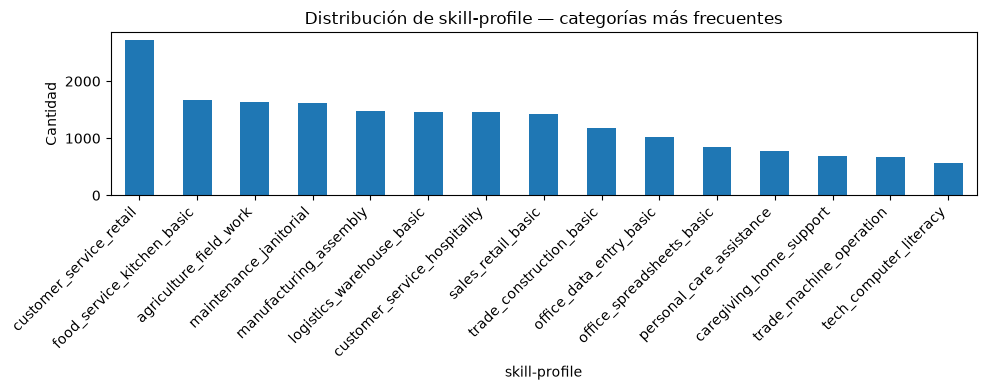

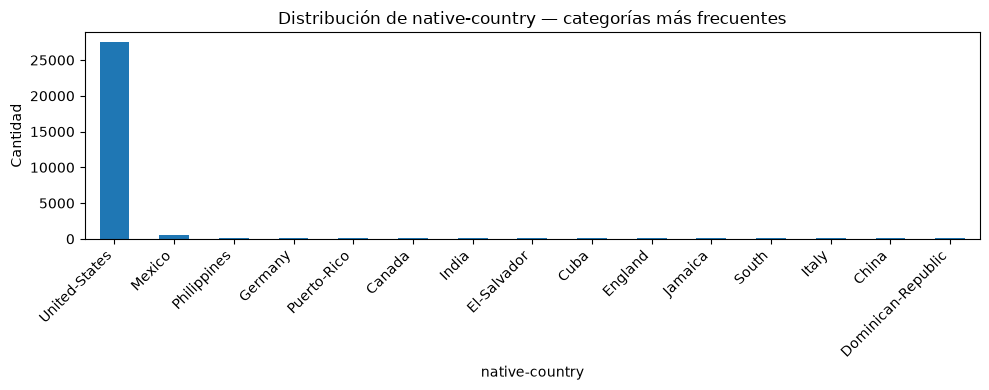

In [7]:
categorical_columns_to_plot = [
    "education",
    "occupation",
    "skill-profile",
    "native-country",
]

for column in categorical_columns_to_plot:
    counts = train_df[column].value_counts().head(15)

    plt.figure(figsize=(10, 4))
    counts.plot(kind="bar")
    plt.title(f"Distribución de {column} — categorías más frecuentes")
    plt.xlabel(column)
    plt.ylabel("Cantidad")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


### Features numéricas

,count,mean,std,min,25%,50%,75%,max
age,30162.0,38.437902,13.134665,17.0,28.0,37.0,47.0,90.0
capital-gain,30162.0,1092.007858,7406.346497,0.0,0.0,0.0,0.0,99999.0
capital-loss,30162.0,88.372489,404.298370,0.0,0.0,0.0,0.0,4356.0
hours-per-week,30162.0,40.931238,11.979984,1.0,40.0,40.0,45.0,99.0


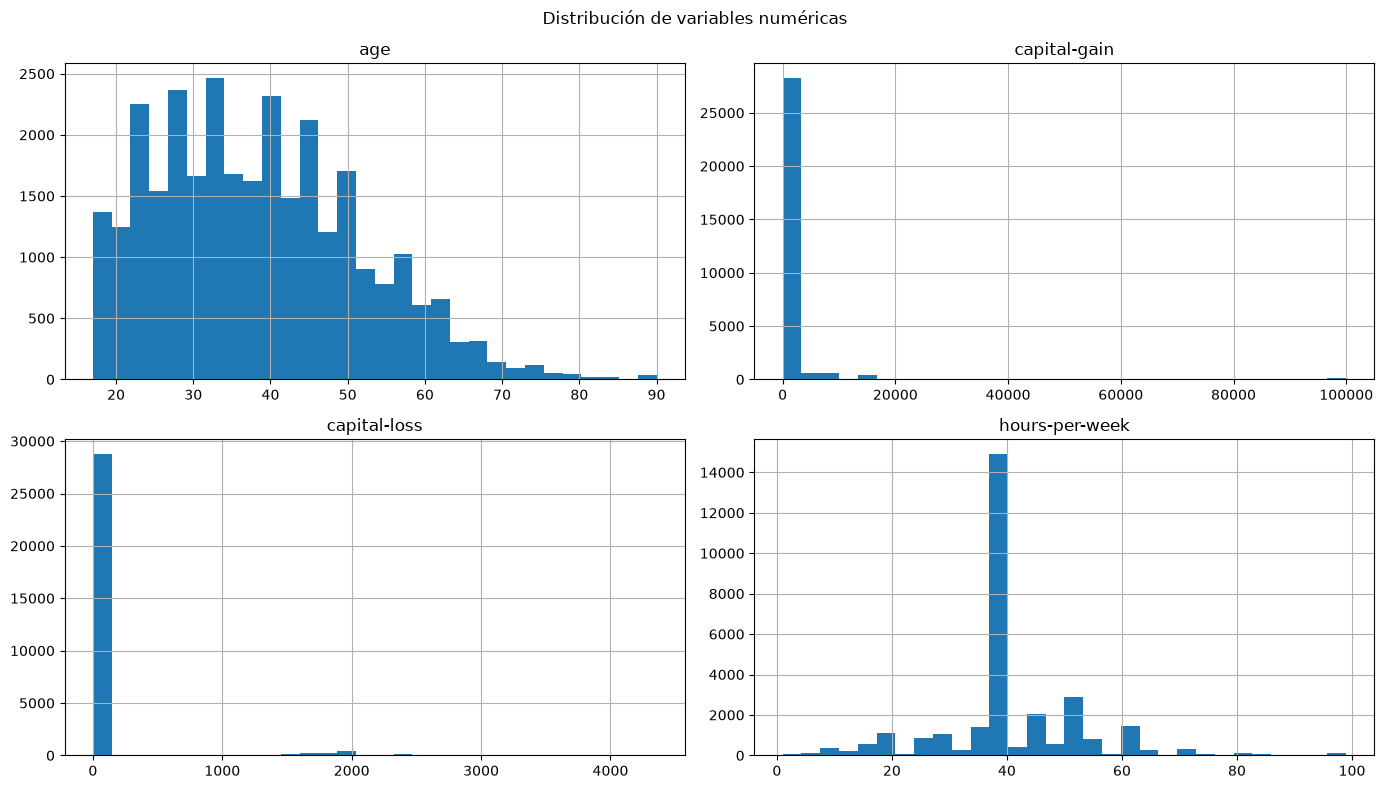

In [8]:
numerical_columns = train_df.select_dtypes(include=np.number).columns.tolist()

display(train_df[numerical_columns].describe().T)

train_df[numerical_columns].hist(
    bins=30,
    figsize=(14, 8),
)

plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()


### Features-Target

In [9]:
train_eda = train_df.copy()

train_eda["income_binary"] = (
    train_eda["income"]
    .map({
        "<=50K": 0,
        ">50K": 1,
    })
)


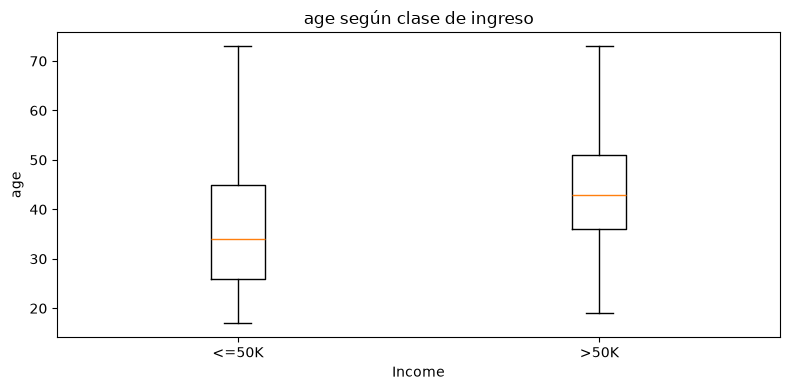

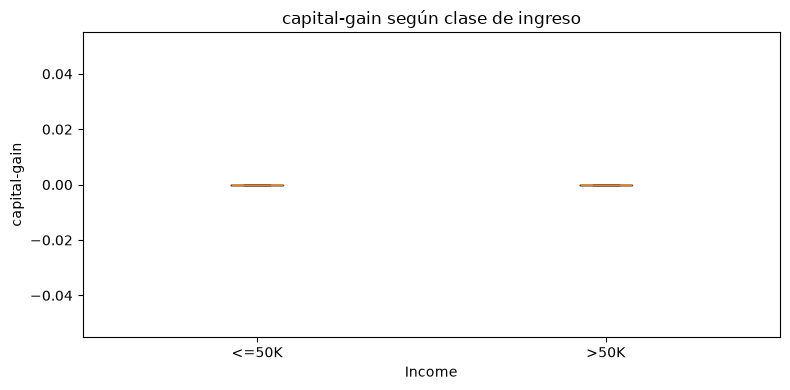

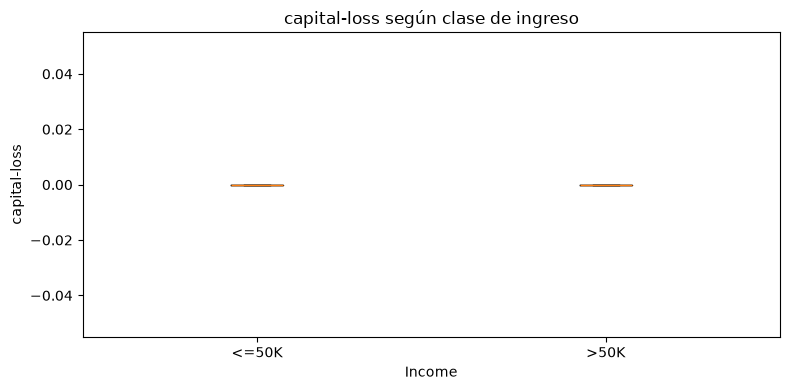

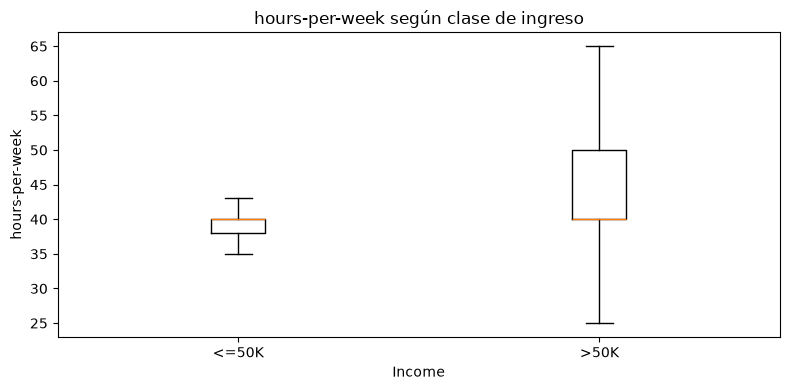

In [10]:
for column in numerical_columns:
    grouped_data = [
        train_eda.loc[
            train_eda["income"] == income_class,
            column
        ]
        for income_class in ["<=50K", ">50K"]
    ]

    plt.figure(figsize=(8, 4))
    plt.boxplot(
        grouped_data,
        tick_labels=["<=50K", ">50K"],
        showfliers=False,
    )
    plt.title(f"{column} según clase de ingreso")
    plt.xlabel("Income")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()


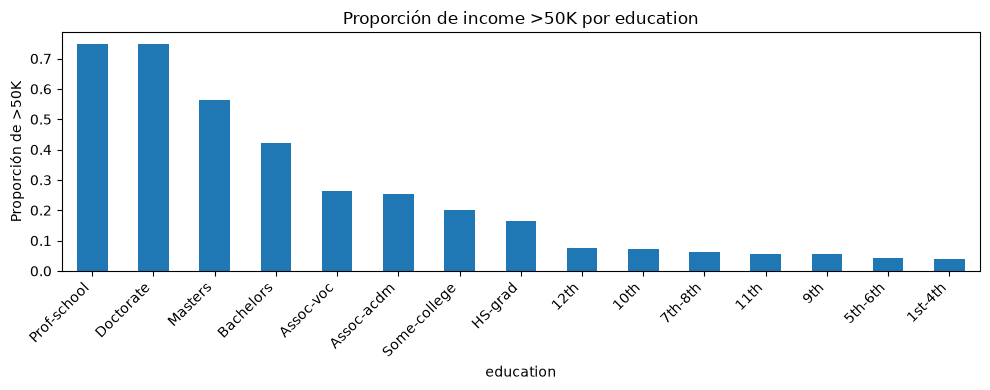

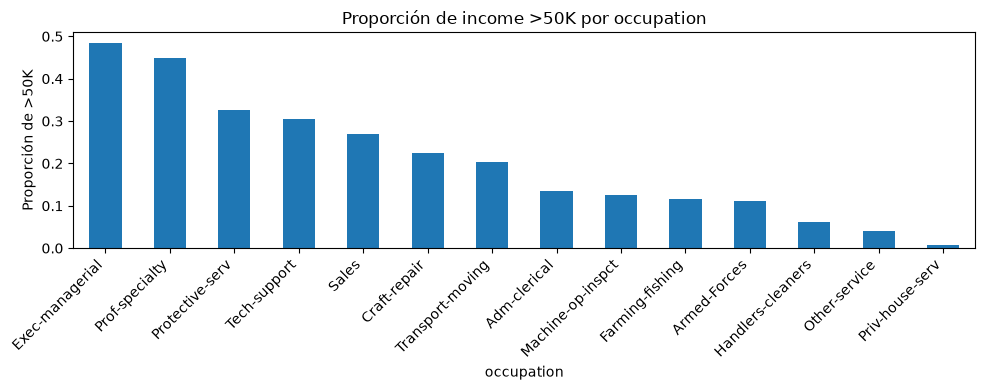

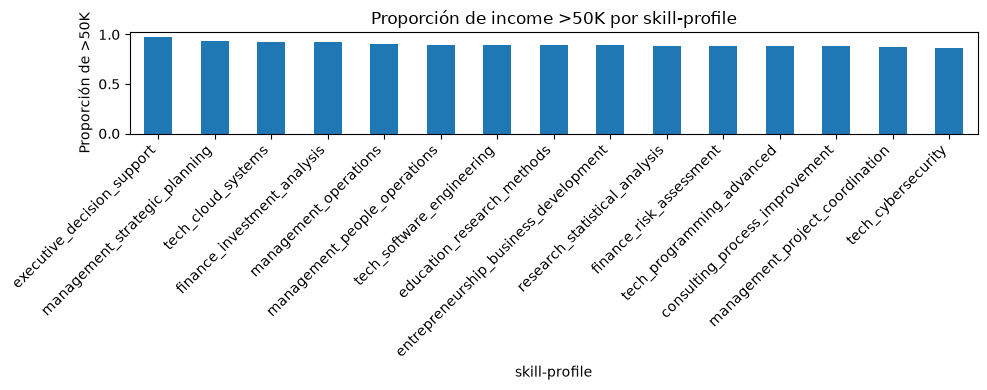

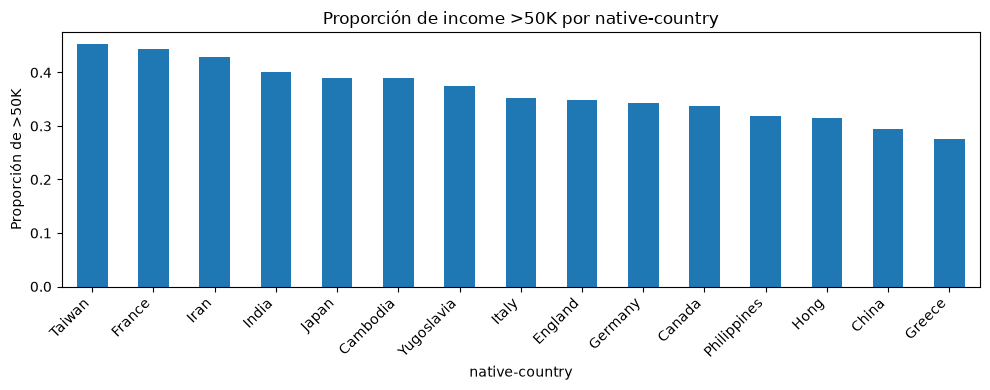

In [11]:
for column in categorical_columns_to_plot:
    category_target_rate = (
        train_eda
        .groupby(column, observed=True)["income_binary"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10, 4))
    category_target_rate["mean"].plot(kind="bar")
    plt.title(f"Proporción de income >50K por {column}")
    plt.xlabel(column)
    plt.ylabel("Proporción de >50K")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


### Transformación del target

In [12]:
target_mapping = {
    "<=50K": 0,
    ">50K": 1,
}

y_train = train_df["income"].map(target_mapping).to_numpy(dtype=np.float32)
y_val = val_df["income"].map(target_mapping).to_numpy(dtype=np.float32)

print("Train:", np.bincount(y_train.astype(int)))
print("Validation:", np.bincount(y_val.astype(int)))


Train: [22654  7508]
Validation: [11360  3700]


### Columnas Finales

In [13]:
embedding_columns = [
    "occupation",
    "skill-profile",
    "native-country",
]

one_hot_columns = [
    "workclass",
    "marital-status",
    "relationship",
    "race",
    "sex",
]

ordinal_columns = [
    "education",
]

numerical_columns = [
    "age",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
]

education_order = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate",
]


## Preprocesamiento para el modelo con embeddings

Se preparan dos tipos de entradas:

- una matriz con variables numéricas, educación ordinal y variables de baja cardinalidad codificadas con one-hot;
- un vector de índices para cada variable que utilizará embedding.

Todos los transformadores se ajustan únicamente con entrenamiento y luego se aplican a validación.


In [14]:
X_train_df = train_df.drop(columns="income").copy()
X_val_df = val_df.drop(columns="income").copy()

# Las variables de capital presentan una distribución muy asimétrica.
for column in ["capital-gain", "capital-loss"]:
    X_train_df[column] = np.log1p(X_train_df[column])
    X_val_df[column] = np.log1p(X_val_df[column])


### Variables numéricas y educación


In [15]:
scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(
    X_train_df[numerical_columns]
)
X_val_numeric = scaler.transform(
    X_val_df[numerical_columns]
)

education_encoder = OrdinalEncoder(
    categories=[education_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

X_train_education = education_encoder.fit_transform(
    X_train_df[ordinal_columns]
)
X_val_education = education_encoder.transform(
    X_val_df[ordinal_columns]
)

education_scaler = StandardScaler()
X_train_education = education_scaler.fit_transform(X_train_education)
X_val_education = education_scaler.transform(X_val_education)

print("Variables numéricas:", X_train_numeric.shape)
print("Education:", X_train_education.shape)


Variables numéricas: (30162, 4)
Education: (30162, 1)


### Variables categóricas de baja cardinalidad


In [16]:
one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

X_train_one_hot = one_hot_encoder.fit_transform(
    X_train_df[one_hot_columns]
)
X_val_one_hot = one_hot_encoder.transform(
    X_val_df[one_hot_columns]
)

X_train_regular = np.concatenate(
    [X_train_numeric, X_train_education, X_train_one_hot],
    axis=1,
).astype(np.float32)

X_val_regular = np.concatenate(
    [X_val_numeric, X_val_education, X_val_one_hot],
    axis=1,
).astype(np.float32)

print("Entrada regular train:", X_train_regular.shape)
print("Entrada regular validation:", X_val_regular.shape)


Entrada regular train: (30162, 32)
Entrada regular validation: (15060, 32)


### Variables categóricas para embeddings

El índice 0 se reserva para posibles categorías desconocidas. Las categorías observadas en entrenamiento comienzan desde el índice 1.


In [17]:
embedding_mappings = {}
X_train_embeddings = {}
X_val_embeddings = {}

for column in embedding_columns:
    categories = sorted(X_train_df[column].unique())
    mapping = {
        category: index + 1
        for index, category in enumerate(categories)
    }

    embedding_mappings[column] = mapping

    X_train_embeddings[column] = (
        X_train_df[column]
        .map(mapping)
        .fillna(0)
        .to_numpy(dtype=np.int64)
    )

    X_val_embeddings[column] = (
        X_val_df[column]
        .map(mapping)
        .fillna(0)
        .to_numpy(dtype=np.int64)
    )

for column in embedding_columns:
    unknown_count = (X_val_embeddings[column] == 0).sum()
    print(f"{column}: {unknown_count} categorías desconocidas en validation")


occupation: 0 categorías desconocidas en validation
skill-profile: 0 categorías desconocidas en validation
native-country: 0 categorías desconocidas en validation


### Tamaño de los embeddings

Se utilizan dimensiones pequeñas para mantener el modelo compacto. Las variables con más categorías reciben embeddings ligeramente mayores.


In [18]:
embedding_info = {}

for column in embedding_columns:
    num_categories = len(embedding_mappings[column]) + 1

    if num_categories <= 20:
        embedding_dim = 4
    elif num_categories <= 50:
        embedding_dim = 8
    else:
        embedding_dim = 12

    embedding_info[column] = {
        "num_categories": num_categories,
        "embedding_dim": embedding_dim,
    }

embedding_info


{'occupation': {'num_categories': 15, 'embedding_dim': 4},
 'skill-profile': {'num_categories': 81, 'embedding_dim': 12},
 'native-country': {'num_categories': 42, 'embedding_dim': 8}}

### Preparación de los datos para PyTorch

Para evitar clases adicionales, los datos se convierten directamente en tensores y se agrupan con `TensorDataset`.


In [19]:
train_dataset = TensorDataset(
    torch.tensor(X_train_regular, dtype=torch.float32),
    torch.tensor(X_train_embeddings["occupation"], dtype=torch.long),
    torch.tensor(X_train_embeddings["skill-profile"], dtype=torch.long),
    torch.tensor(X_train_embeddings["native-country"], dtype=torch.long),
    torch.tensor(y_train, dtype=torch.float32),
)

val_dataset = TensorDataset(
    torch.tensor(X_val_regular, dtype=torch.float32),
    torch.tensor(X_val_embeddings["occupation"], dtype=torch.long),
    torch.tensor(X_val_embeddings["skill-profile"], dtype=torch.long),
    torch.tensor(X_val_embeddings["native-country"], dtype=torch.long),
    torch.tensor(y_val, dtype=torch.float32),
)

BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

regular, occupation, skill, country, target = next(iter(train_loader))

print("Entrada regular:", regular.shape)
print("Occupation:", occupation.shape)
print("Skill profile:", skill.shape)
print("Native country:", country.shape)
print("Target:", target.shape)


Entrada regular: torch.Size([256, 32])
Occupation: torch.Size([256])
Skill profile: torch.Size([256])
Native country: torch.Size([256])
Target: torch.Size([256])


## b) Modelo con embeddings

La red recibe por un lado las 32 variables ya procesadas y, por otro, los índices de las tres variables categóricas de alta cardinalidad. Los embeddings se concatenan con la entrada regular antes de pasar por las capas densas.


In [20]:
class EmbeddingModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.occupation_embedding = nn.Embedding(15, 4)
        self.skill_embedding = nn.Embedding(81, 12)
        self.country_embedding = nn.Embedding(42, 8)

        self.network = nn.Sequential(
            nn.Linear(56, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, regular, occupation, skill, country):
        x = torch.cat([
            regular,
            self.occupation_embedding(occupation),
            self.skill_embedding(skill),
            self.country_embedding(country),
        ], dim=1)

        return self.network(x).squeeze(1)


embedding_model = EmbeddingModel().to(device)

print(embedding_model)
print(
    "Parámetros entrenables:",
    sum(p.numel() for p in embedding_model.parameters() if p.requires_grad),
)


EmbeddingModel(
  (occupation_embedding): Embedding(15, 4)
  (skill_embedding): Embedding(81, 12)
  (country_embedding): Embedding(42, 8)
  (network): Sequential(
    (0): Linear(in_features=56, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Parámetros entrenables: 7129


### Entrenamiento

Durante cada época se calculan accuracy y F1 macro tanto para entrenamiento como para validación.


In [21]:
def train_model(model, train_loader, val_loader, epochs=10, use_embeddings=True):
    loss_function = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    history = {
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": [],
    }

    for epoch in range(epochs):
        for split, loader in [("train", train_loader), ("val", val_loader)]:
            model.train(split == "train")
            targets_all, predictions_all = [], []

            for batch in loader:
                batch = [tensor.to(device) for tensor in batch]
                targets = batch[-1]

                if split == "train":
                    optimizer.zero_grad()

                with torch.set_grad_enabled(split == "train"):
                    if use_embeddings:
                        logits = model(*batch[:-1])
                    else:
                        logits = model(batch[0]).squeeze(1)

                    loss = loss_function(logits, targets)

                    if split == "train":
                        loss.backward()
                        optimizer.step()

                predictions = (torch.sigmoid(logits) >= 0.5).int()
                targets_all.extend(targets.cpu().numpy())
                predictions_all.extend(predictions.cpu().numpy())

            history[f"{split}_acc"].append(
                accuracy_score(targets_all, predictions_all)
            )
            history[f"{split}_f1"].append(
                f1_score(targets_all, predictions_all, average="macro")
            )

        print(
            f"Epoch {epoch + 1:02d} | "
            f"train acc: {history['train_acc'][-1]:.4f} | "
            f"val acc: {history['val_acc'][-1]:.4f} | "
            f"val F1: {history['val_f1'][-1]:.4f}"
        )

    return history


embedding_history = train_model(
    embedding_model,
    train_loader,
    val_loader,
)


Epoch 01 | train acc: 0.8067 | val acc: 0.8580 | val F1: 0.7974
Epoch 02 | train acc: 0.8570 | val acc: 0.8708 | val F1: 0.8167
Epoch 03 | train acc: 0.8680 | val acc: 0.8759 | val F1: 0.8292
Epoch 04 | train acc: 0.8738 | val acc: 0.8795 | val F1: 0.8302
Epoch 05 | train acc: 0.8790 | val acc: 0.8819 | val F1: 0.8334
Epoch 06 | train acc: 0.8807 | val acc: 0.8836 | val F1: 0.8381
Epoch 07 | train acc: 0.8829 | val acc: 0.8865 | val F1: 0.8435
Epoch 08 | train acc: 0.8846 | val acc: 0.8864 | val F1: 0.8414
Epoch 09 | train acc: 0.8843 | val acc: 0.8857 | val F1: 0.8394
Epoch 10 | train acc: 0.8874 | val acc: 0.8857 | val F1: 0.8388


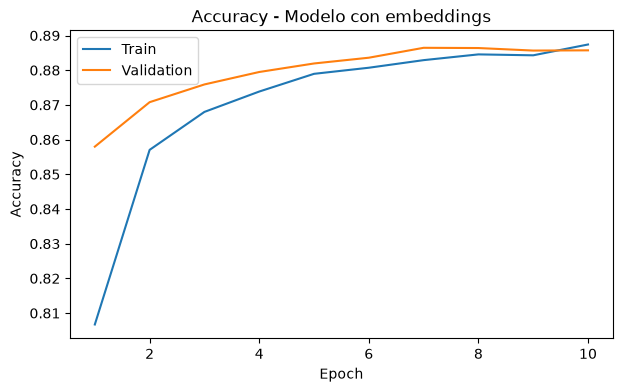

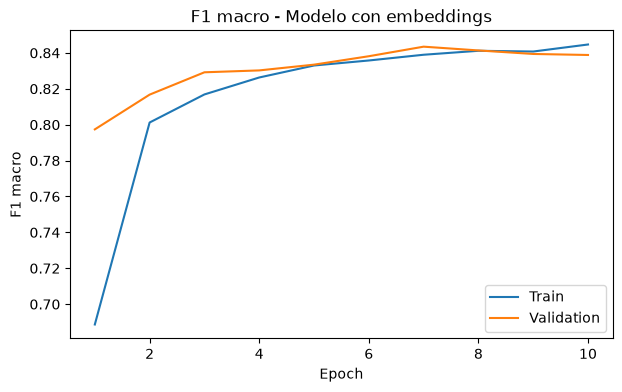

In [22]:
def plot_history(history, title):
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy - {title}")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_f1"], label="Train")
    plt.plot(epochs, history["val_f1"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("F1 macro")
    plt.title(f"F1 macro - {title}")
    plt.legend()
    plt.show()


plot_history(embedding_history, "Modelo con embeddings")


              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.93     11360
        >50K       0.81      0.70      0.75      3700

    accuracy                           0.89     15060
   macro avg       0.86      0.82      0.84     15060
weighted avg       0.88      0.89      0.88     15060



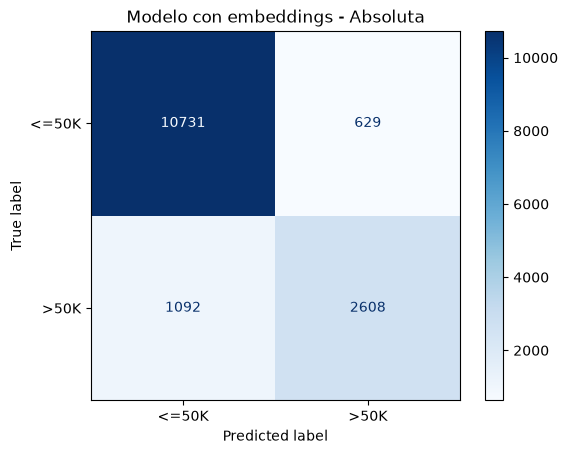

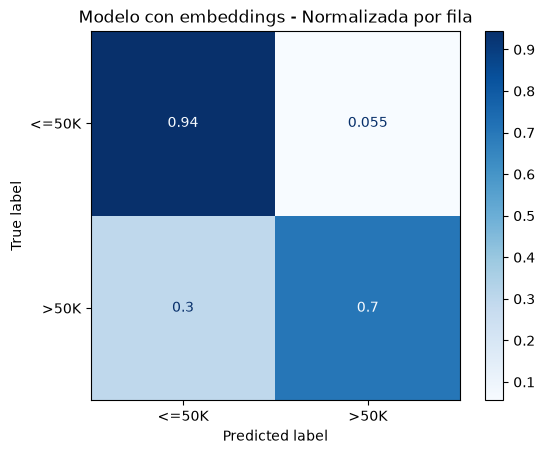

In [23]:
def evaluate_model(model, loader, title, use_embeddings=True):
    model.eval()
    targets_all, predictions_all = [], []

    with torch.no_grad():
        for batch in loader:
            batch = [tensor.to(device) for tensor in batch]

            if use_embeddings:
                logits = model(*batch[:-1])
            else:
                logits = model(batch[0]).squeeze(1)

            predictions = (torch.sigmoid(logits) >= 0.5).int()

            targets_all.extend(batch[-1].cpu().numpy())
            predictions_all.extend(predictions.cpu().numpy())

    targets_all = np.array(targets_all).astype(int)
    predictions_all = np.array(predictions_all)

    print(
        classification_report(
            targets_all,
            predictions_all,
            target_names=["<=50K", ">50K"],
        )
    )

    for normalize, subtitle in [
        (None, "Absoluta"),
        ("true", "Normalizada por fila"),
    ]:
        ConfusionMatrixDisplay.from_predictions(
            targets_all,
            predictions_all,
            display_labels=["<=50K", ">50K"],
            normalize=normalize,
            cmap="Blues",
        )
        plt.title(f"{title} - {subtitle}")
        plt.show()

    return targets_all, predictions_all


embedding_targets, embedding_predictions = evaluate_model(
    embedding_model,
    val_loader,
    "Modelo con embeddings",
)


## c) Modelo sin embeddings

Para la segunda comparación, las tres variables anteriores también se codifican con one-hot. Se mantienen las mismas capas densas y activaciones, pero se elimina el dropout como indica la consigna.


In [24]:
all_one_hot_columns = one_hot_columns + embedding_columns

full_one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

X_train_full_one_hot = full_one_hot_encoder.fit_transform(
    X_train_df[all_one_hot_columns]
)
X_val_full_one_hot = full_one_hot_encoder.transform(
    X_val_df[all_one_hot_columns]
)

X_train_no_embeddings = np.concatenate(
    [X_train_numeric, X_train_education, X_train_full_one_hot],
    axis=1,
).astype(np.float32)

X_val_no_embeddings = np.concatenate(
    [X_val_numeric, X_val_education, X_val_full_one_hot],
    axis=1,
).astype(np.float32)

train_loader_no_embeddings = DataLoader(
    TensorDataset(
        torch.tensor(X_train_no_embeddings),
        torch.tensor(y_train),
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader_no_embeddings = DataLoader(
    TensorDataset(
        torch.tensor(X_val_no_embeddings),
        torch.tensor(y_val),
    ),
    batch_size=BATCH_SIZE,
)

print("Entrada sin embeddings:", X_train_no_embeddings.shape[1])


Entrada sin embeddings: 167


In [25]:
no_embedding_model = nn.Sequential(
    nn.Linear(X_train_no_embeddings.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
).to(device)

print(no_embedding_model)
print(
    "Parámetros entrenables:",
    sum(p.numel() for p in no_embedding_model.parameters() if p.requires_grad),
)


Sequential(
  (0): Linear(in_features=167, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)
Parámetros entrenables: 12865


Epoch 01 | train acc: 0.8267 | val acc: 0.8739 | val F1: 0.8248
Epoch 02 | train acc: 0.8800 | val acc: 0.8853 | val F1: 0.8402
Epoch 03 | train acc: 0.8859 | val acc: 0.8867 | val F1: 0.8397
Epoch 04 | train acc: 0.8874 | val acc: 0.8890 | val F1: 0.8402
Epoch 05 | train acc: 0.8890 | val acc: 0.8892 | val F1: 0.8455
Epoch 06 | train acc: 0.8913 | val acc: 0.8887 | val F1: 0.8458
Epoch 07 | train acc: 0.8919 | val acc: 0.8865 | val F1: 0.8416
Epoch 08 | train acc: 0.8919 | val acc: 0.8869 | val F1: 0.8451
Epoch 09 | train acc: 0.8936 | val acc: 0.8877 | val F1: 0.8411
Epoch 10 | train acc: 0.8944 | val acc: 0.8880 | val F1: 0.8439


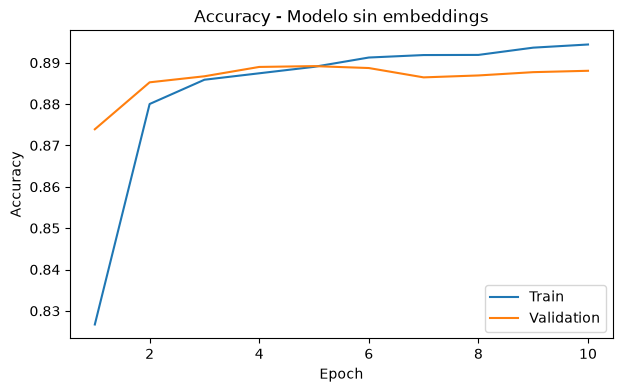

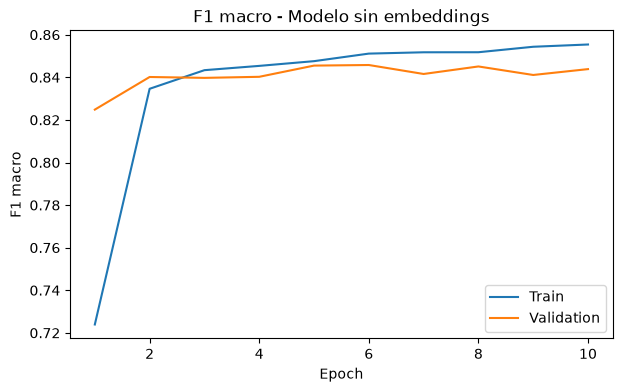

In [26]:
no_embedding_history = train_model(
    no_embedding_model,
    train_loader_no_embeddings,
    val_loader_no_embeddings,
    use_embeddings=False,
)

plot_history(no_embedding_history, "Modelo sin embeddings")


              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.93     11360
        >50K       0.80      0.72      0.76      3700

    accuracy                           0.89     15060
   macro avg       0.86      0.83      0.84     15060
weighted avg       0.89      0.89      0.89     15060



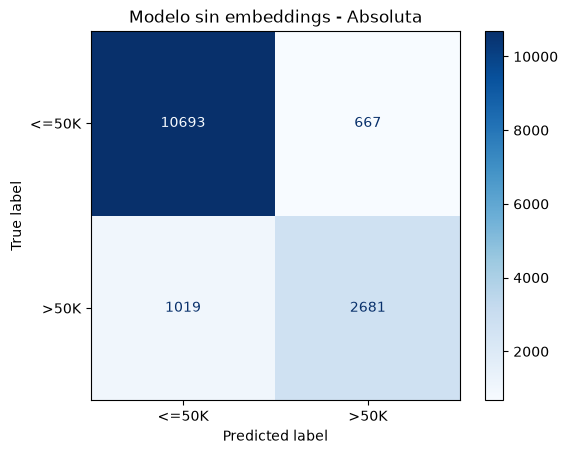

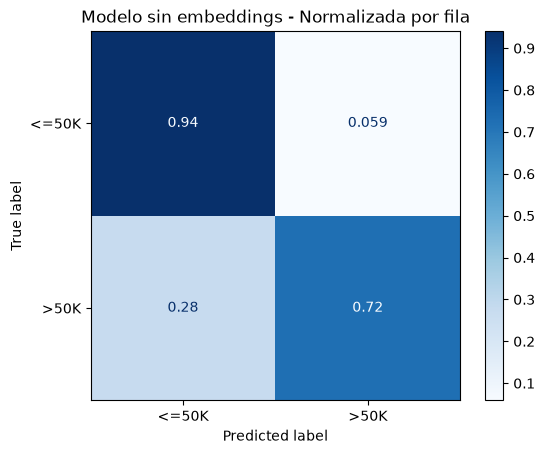

In [27]:
no_embedding_targets, no_embedding_predictions = evaluate_model(
    no_embedding_model,
    val_loader_no_embeddings,
    "Modelo sin embeddings",
    use_embeddings=False,
)


## d) Comparación final


In [28]:
embedding_parameters = sum(
    p.numel() for p in embedding_model.parameters() if p.requires_grad
)
no_embedding_parameters = sum(
    p.numel() for p in no_embedding_model.parameters() if p.requires_grad
)

comparison = pd.DataFrame({
    "Modelo": ["Con embeddings", "Sin embeddings"],
    "Accuracy validación": [
        accuracy_score(embedding_targets, embedding_predictions),
        accuracy_score(no_embedding_targets, no_embedding_predictions),
    ],
    "F1 macro validación": [
        f1_score(embedding_targets, embedding_predictions, average="macro"),
        f1_score(no_embedding_targets, no_embedding_predictions, average="macro"),
    ],
    "Entradas finales": [56, X_train_no_embeddings.shape[1]],
    "Parámetros entrenables": [
        embedding_parameters,
        no_embedding_parameters,
    ],
})

display(comparison.round(4))


,Modelo,Accuracy validación,F1 macro validación,Entradas finales,Parámetros entrenables
0,Con embeddings,0.8857,0.8388,56,7129
1,Sin embeddings,0.8880,0.8439,167,12865


### Conclusiones

Los dos modelos obtuvieron resultados muy parecidos. En esta ejecución, el modelo sin embeddings tuvo una pequeña ventaja: alcanzó una accuracy de 0,8880 y un F1 macro de 0,8439, frente a 0,8857 y 0,8388 del modelo con embeddings.

La diferencia de desempeño es chica, pero la representación cambia bastante. Con embeddings, la entrada a la red se reduce de 167 a 56 valores y la cantidad de parámetros entrenables baja de 12.865 a 7.129.

En este caso, los embeddings no mejoraron las métricas, aunque permitieron construir un modelo bastante más compacto. Esto muestra que su principal ventaja no siempre es obtener una mejor clasificación, sino representar variables categóricas grandes usando menos dimensiones y parámetros.
